# Automatic Panoramic Image Stitching using Invariant Features

Describe un método avanzado para crear imágenes panorámicas utilizando características invariantes.

In [13]:
import os  # for file handling
import cv2 as cv  # for image processing
import numpy as np  # for array manipulation
import matplotlib.pyplot as plt  # for plotting

In [14]:
IMG_PATH = '.\\..\\resources\\img\\'  # Path to images
directories = [entry for entry in os.listdir(IMG_PATH) if os.path.isdir(os.path.join(IMG_PATH, entry))]  # Filter out directories

In [15]:
selected_dir: int = 6  # Select directory to read images from
print(IMG_PATH + f"{directories[selected_dir]}\\")  # print path to selected directory

imgs = [cv.cvtColor(cv.imread(IMG_PATH + f"{directories[selected_dir]}\\{i}"), cv.COLOR_BGR2RGB) for i in os.listdir(IMG_PATH + f"{directories[selected_dir]}\\")][::-1]
for img in imgs:
    print(f"{img.shape} {img.dtype}")

.\..\resources\img\a6\
(4000, 3000, 3) uint8
(4000, 3000, 3) uint8
(4000, 3000, 3) uint8
(4000, 3000, 3) uint8


In [16]:
# reduce image size to 1/4
imgs = [cv.resize(img, (int(img.shape[1] / 2), int(img.shape[0] / 2))) for img in imgs]

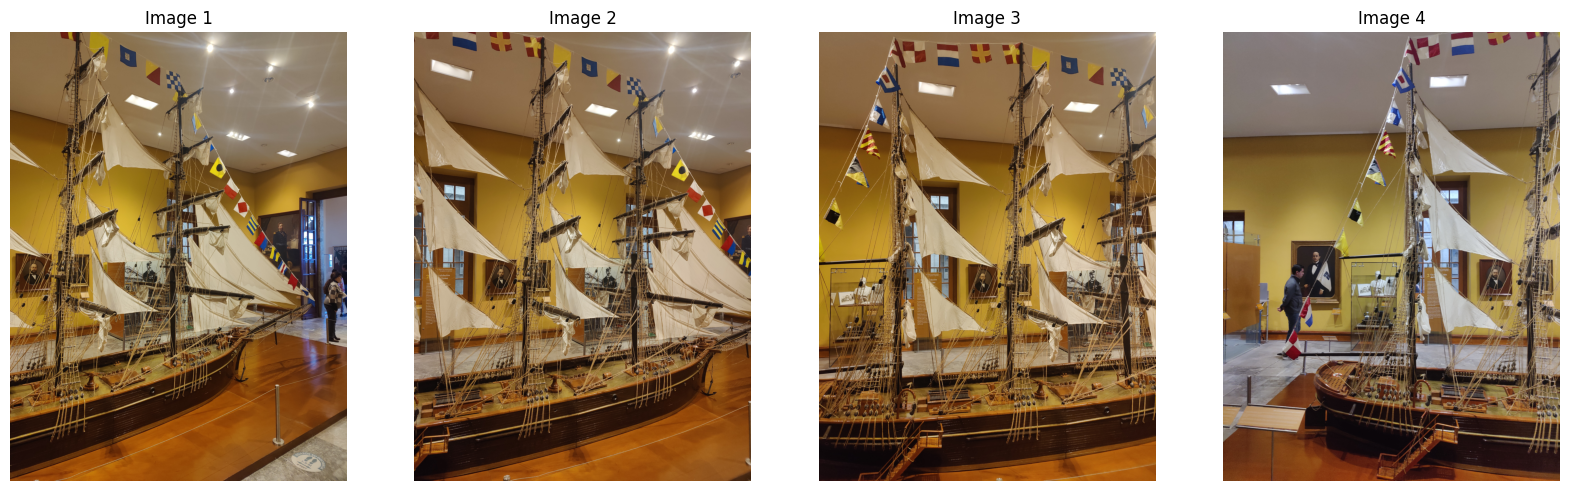

In [17]:
# Show images
plt.figure(figsize=(20,15))  # Set figure size
for i in range(len(imgs)):  # Loop through images
    plt.subplot(1, len(imgs), i + 1)  # Set subplot
    plt.title(f'Image {i + 1}')  # Set title
    plt.axis('off')  # Disable axis
    plt.imshow(imgs[i])  # Show image

### 1. Extracción de Características SIFT

Se extraen características SIFT (Scale-Invariant Feature Transform) de todas las imágenes. Las características SIFT son invariantes a cambios de escala y rotación, y parcialmente invariantes a cambios de iluminación y perspectiva.

In [18]:
def extract_features(image):
    """
    Extract features from an image using SIFT and return keypoints and descriptors.

    :param image: Image to extract features from

    :return: Keypoints and descriptors
    """
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

### 2. Matching de Características

Se buscan los vecinos más cercanos de cada característica SIFT entre todas las imágenes utilizando un árbol k-d. Este paso identifica posibles correspondencias de características entre pares de imágenes.

Este paso se puede acelerar utilizando un árbol k-d aproximado, como el FLANN (Fast Library for Approximate Nearest Neighbors).

Incluye el ratio test de Lowe para eliminar correspondencias ambiguas. El ratio test de Lowe consiste en descartar una correspondencia si el vecino más cercano es muy similar al segundo vecino más cercano.

In [19]:
def match_features(descriptors1, descriptors2) -> list:
    """
    Find matches between two sets of descriptors.

    :param descriptors1: First set of descriptors
    :param descriptors2: Second set of descriptors

    :return: Matches between the two sets of descriptors
    """
    bf = cv.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)
    return [m for m, n in matches if m.distance < 0.75 * n.distance]

### 3. Estimación Robusta de Homografía con RANSAC

Para cada par de imágenes con suficientes matches, se utiliza RANSAC (Random Sample Consensus) para estimar una homografía robusta, ignorando outliers. RANSAC selecciona subconjuntos de correspondencias y calcula homografías, eligiendo la que tiene el mayor número de inliers.

In [20]:
def find_homography(keypoints1, keypoints2, matches):
    """
    Find homography between two sets of keypoints.

    :param keypoints1: First set of keypoints
    :param keypoints2: Second set of keypoints
    :param matches: Matches between the two sets of keypoints
    
    :return: Homography between the two sets of keypoints
    """
    if len(matches) > 4:
        src_pts = np.float32([keypoints1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

        H, _ = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        return H
    else:
        return None
    

def compute_homography(i):
    """
    Compute homography between two consecutive images.
    
    :param i: Index of first image
    
    :return: Homography between the two images
    """
    keypoints1, descriptors1 = extract_features(imgs[i])
    keypoints2, descriptors2 = extract_features(imgs[i + 1])
    if (H := find_homography(keypoints1, keypoints2, match_features(descriptors1, descriptors2))) is None:
        print(f"No se pudo encontrar homografía suficiente entre la imagen {i} y {i + 1}")
    return H

### 4. Ajuste de Paquete (Bundle Adjustment)

Una vez identificadas las correspondencias y las homografías iniciales, se utiliza el ajuste de paquete para refinar simultáneamente todas las homografías, mejorando la alineación global de las imágenes.

In [21]:
def stitch_images(images, homographies):
    """
    Stitch a series of images using the given homographies.

    :param images: List of images to stitch
    :param homographies: Homographies between consecutive images

    :return: Stitched image
    """
    result = images[0]
    for i, H in enumerate(homographies):
        width = result.shape[1] + images[i + 1].shape[1]
        height = result.shape[0]
        result = cv.warpPerspective(result, H, (width, height))
        result[0:images[i + 1].shape[0], 0:images[i + 1].shape[1]] = images[i + 1]
    return result

In [22]:
panorama = stitch_images(imgs, [compute_homography(i) for i in range(len(imgs) - 1)])

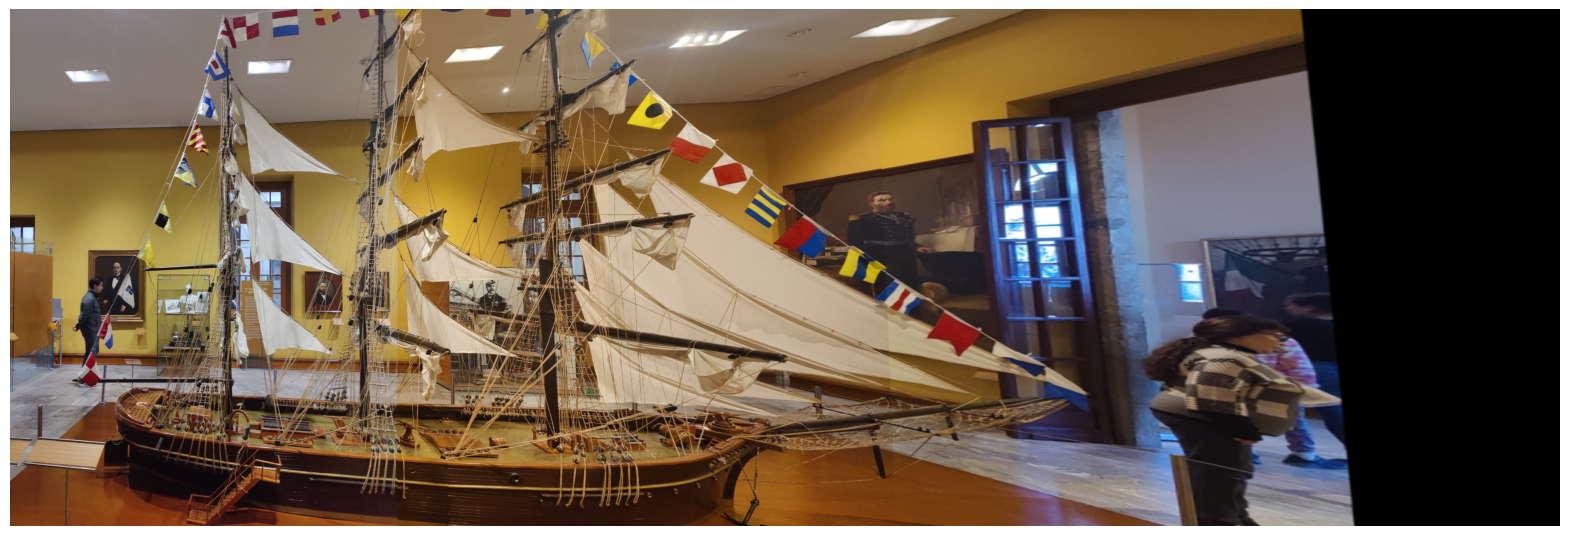

In [23]:
plt.figure(figsize=(20,15))
plt.imshow(panorama)
plt.axis('off')
plt.show()

In [24]:
# store the image in the output directory with the name of the selected directory
cv.imwrite(f"{IMG_PATH}\\processed\\{directories[selected_dir]}.jpg", cv.cvtColor(panorama, cv.COLOR_RGB2BGR))

True